### Patch Extraction Notebook

This notebook will have as inputs the crown delineation shapefiles:

 - manually segmented
 - automatic (CanopyRS) 

The manually segmented shapefile will be used to generate the reference dataset, used to train and evaluate the closed set models, and also
calibrate and evaluate the open set thresholds.

The automatically segmented polygons shapefile will be used to generate the large-scale inference of the best open set model, after every test.

### Outputs
This notebook will:

 - extract patches for training, validation and large scale inference
 - split the patches used for the models training and validation (known species) into train/val folders, with subfolders for each species
 - group the patches of unknown species (for the model) in the 'unknown' folder, grouped into subfolders for each species

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask
import numpy as np
import os

In [ ]:
poligons = gpd.read_file(r"I:\data\manual_itcs.shp")

In [ ]:
print(poligons)

In [ ]:
# Convert to WGS 84 if not already
if poligonos.crs is None or poligonos.crs.to_epsg() != 4326:
    poligonos = poligonos.to_crs(epsg=31982)

In [ ]:
# Load raster
ortho_path = r"I:\data\ortho.tif"
ortho = rasterio.open(ortho_path)

In [ ]:
# Load second raster (adjacent to the original orthomosaic, contains some patches)

ortho_entornos_path = r"I:\data\entornos.tif"
entornos = rasterio.open(ortho_entornos_path)

In [ ]:
#check CRS compatibility
crs_ortho = ortho.crs
poligonos = poligonos.to_crs(crs_ortho)


print("CRS do raster (ortho):", ortho.crs)
print("CRS dos polígonos (poligonos):", poligonos.crs)
print('CRS do raster dos entornos:', entornos.crs)

CRS do raster (ortho): PROJCS["unnamed",GEOGCS["SIRGAS 2000",DATUM["unnamed",SPHEROID["GRS 1980",6378137,298.257222101004]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-51],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
CRS dos polígonos (poligonos): EPSG:31982
CRS do raster dos entornos: PROJCS["unnamed",GEOGCS["SIRGAS 2000",DATUM["unnamed",SPHEROID["GRS 1980",6378137,298.257222101004]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-51],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AX

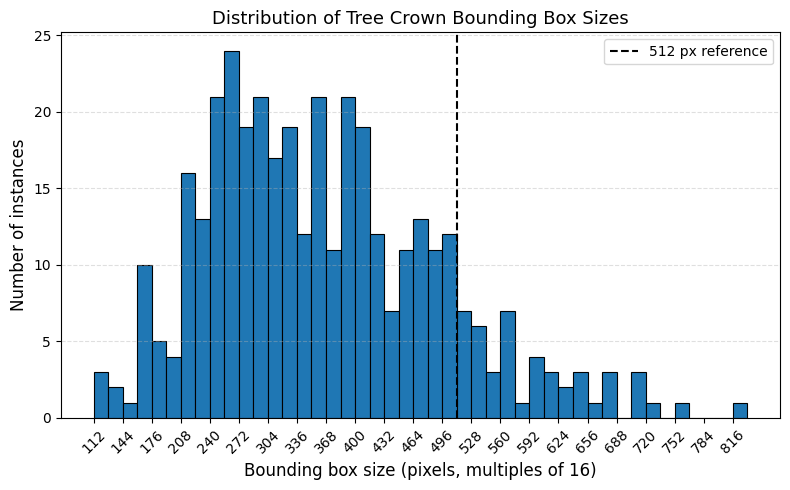

In [ ]:
# Check Bounding box size distribuition. 

import numpy as np
import matplotlib.pyplot as plt

# Get orthomosaic resolution (m/pixel)
res_x = abs(ortho.transform.a)
res_y = abs(ortho.transform.e)

# Compute bounding box sizes in meters
widths = []
heights = []

for geom in poligonos.geometry.dropna():
    if not geom.is_empty:
        minx, miny, maxx, maxy = geom.bounds
        widths.append(maxx - minx)
        heights.append(maxy - miny)

widths = np.array(widths)
heights = np.array(heights)

# Convert to pixels
pixel_widths = widths / res_x
pixel_heights = heights / res_y

# Use the maximum side of each bounding box
max_sizes = np.maximum(pixel_widths, pixel_heights)

# Round to nearest multiple of 16
sizes_16 = np.ceil(max_sizes / 16) * 16

# Define bins (multiples of 16)
min_bin = int(sizes_16.min())
max_bin = int(sizes_16.max())

bins = np.arange(min_bin, max_bin + 32, 16)

# Plot (publication-style)
plt.figure(figsize=(8, 5))

plt.hist(
    sizes_16,
    bins=bins,
    edgecolor="black",
    linewidth=0.8
)

# Vertical reference line at 512 px
plt.axvline(
    x=512,
    linestyle="--",
    color='black',
    linewidth=1.5,
    label="512 px reference"
)

plt.xlabel("Bounding box size (pixels, multiples of 16)", fontsize=12)
plt.ylabel("Number of instances", fontsize=12)
plt.title("Distribution of Tree Crown Bounding Box Sizes", fontsize=13)

plt.xticks(bins[::2], rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Check some Orthomosaic configurations

import numpy as np
import rasterio

# --- PATCH SIZE ---
TARGET_SIZE = (512, 512)  # (W, H) para PIL

# --- ORTHO METADATA ---
ORTHO_CRS   = ortho.crs
ORTHO_COUNT = ortho.count
ORTHO_DTYPE = ortho.dtypes[0]
ORTHO_NODATA = ortho.nodata  # pode ser None
RES_X = abs(ortho.transform.a)
RES_Y = abs(ortho.transform.e)

# --- RGB BAND SELECTION (0-based indices for numpy) ---
# Prefer declared color interpretation; otherwise assume first 3 bands are RGB.
try:
    ci = list(ortho.colorinterp)
    R = ci.index(rasterio.enums.ColorInterp.red)
    G = ci.index(rasterio.enums.ColorInterp.green)
    B = ci.index(rasterio.enums.ColorInterp.blue)
    RGB_IDX = (R, G, B)
    RGB_SOURCE = "colorinterp"
except Exception:
    if ORTHO_COUNT >= 3:
        RGB_IDX = (0, 1, 2)
        RGB_SOURCE = "first_3_bands"
    else:
        RGB_IDX = (0,)
        RGB_SOURCE = "single_band"

# --- DTYPE → UINT8 CONVERSION (deterministic for THIS ortho) ---
# Output rule: outside polygon = 0 (black). Inside uses linear scaling.
# For uint8: keep as is.
# For uint16: scale by 257 (0..65535 -> 0..255).
# For float: clip to [0,1] then *255 (assumes reflectance-like product).
if ORTHO_DTYPE == "uint8":
    def TO_UINT8(x):
        return x.astype(np.uint8)

elif ORTHO_DTYPE == "uint16":
    def TO_UINT8(x):
        # integer-safe downscale (keeps 0 as 0)
        return (x // 257).astype(np.uint8)

elif ORTHO_DTYPE in ("float32", "float64"):
    def TO_UINT8(x):
        x = np.clip(x, 0.0, 1.0)
        return (x * 255.0).astype(np.uint8)

else:
    raise ValueError(f"Unsupported ortho dtype: {ORTHO_DTYPE}")

print("=== ORTHO CONFIG (for patch extraction) ===")
print("CRS:", ORTHO_CRS)
print("Bands:", ORTHO_COUNT, "| dtype:", ORTHO_DTYPE, "| nodata:", ORTHO_NODATA)
print("Resolution (m):", RES_X, RES_Y)
print("RGB indices (0-based):", RGB_IDX, "| source:", RGB_SOURCE)
print("Target patch size:", TARGET_SIZE)


=== ORTHO CONFIG (for patch extraction) ===
CRS: PROJCS["unnamed",GEOGCS["SIRGAS 2000",DATUM["unnamed",SPHEROID["GRS 1980",6378137,298.257222101004]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-51],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Bands: 3 | dtype: uint8 | nodata: None
Resolution (m): 0.0199999999999987 0.020000000000011425
RGB indices (0-based): (0, 1, 2) | source: colorinterp
Target patch size: (512, 512)


In [ ]:
import os
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import box
from PIL import Image, ImageOps

# =========================
# CONFIG
# =========================
poligonos_path = r"I:\data\poligonos_copas_processed.shp"
ortho_path = r"I:\data\ortho.tif"   # <-- change to 'entornos if you want to extract the patches present in the second orthomosaic.
                                    #     This was run 2 times ('ortho' and 'entornos'), and the patches were manually compiled in a single folder
                                
output_dir = r"I:\data\patches" 
target_size = (512, 512)  # (W, H)

os.makedirs(output_dir, exist_ok=True)

# =========================
# LOAD
# =========================
poligonos = gpd.read_file(poligonos_path)
ortho = rasterio.open(ortho_path)

# CRS check (reproject polygons to raster CRS)
if poligonos.crs != ortho.crs:
    poligonos = poligonos.to_crs(ortho.crs)

# Filter polygons intersecting raster bounds
raster_bbox = box(*ortho.bounds)
poligonos = poligonos[poligonos.geometry.intersects(raster_bbox)].reset_index(drop=True)

print(f"Polygons to process: {len(poligonos)}")
print(f"Raster bands/dtype: {ortho.count} / {ortho.dtypes[0]}")

# =========================
# EXTRACT + SAVE
# =========================
for idx in range(len(poligonos)):
    geom = poligonos.geometry.iloc[idx]
    photo_code = poligonos["photo_code"].iloc[idx]

    out, _ = mask(
        ortho,
        [geom],
        crop=True,
        filled=True,
        nodata=0,          # outside polygon -> black
        all_touched=True
    )  # (3, H, W), uint8

    if out.size == 0 or out.shape[1] == 0 or out.shape[2] == 0:
        print(f"⚠️ Empty crop for idx={idx} ({photo_code}). Skipping...")
        continue

    # (3, H, W) -> (H, W, 3)
    out = np.transpose(out, (1, 2, 0))

    # Create RGB image (your ortho is 3-band uint8)
    img = Image.fromarray(out, mode="RGB")

    # Pad to fixed size with black background (keeps aspect ratio)
    img = ImageOps.pad(
        img,
        size=target_size,
        color=(0, 0, 0),
        centering=(0.5, 0.5)
    )

    out_path = os.path.join(output_dir, f"{photo_code}.png")
    img.save(out_path)

print("✅ Done.")


In [ ]:
# Check for unmatched patches between the polygons shapefile and 


import os
import shutil
import geopandas as gpd

# =========================
# CONFIG
# =========================
patches_dir = r"I:\data\patches"  # pasta única com os patches
shp_path    = r"I:\data\manual_itcs.shp"

PHOTO_COL   = "photo_code"
SPECIES_COL = "species"   # <-- troque se no seu shapefile for outro nome (ex: "especie", "sp", "species_id")

# escolha: mover ou copiar
MODE = "move"  # "move" ou "copy"

# extensões aceitas
EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff"}

# =========================
# LOAD LOOKUP (photo_code -> species)
# =========================
gdf = gpd.read_file(shp_path)

# mantém só as colunas necessárias
gdf = gdf[[PHOTO_COL, SPECIES_COL]].copy()

# normaliza pra string
gdf[PHOTO_COL] = gdf[PHOTO_COL].astype(str)
gdf[SPECIES_COL] = gdf[SPECIES_COL].astype(str)

# dicionário de lookup
photo_to_species = dict(zip(gdf[PHOTO_COL], gdf[SPECIES_COL]))

print(f"Lookup loaded: {len(photo_to_species)} photo_code -> species")

# =========================
# ORGANIZE PATCHES
# =========================
n_total = 0
n_matched = 0
n_unmatched = 0
unmatched = []

for fn in os.listdir(patches_dir):
    src = os.path.join(patches_dir, fn)
    if not os.path.isfile(src):
        continue

    ext = os.path.splitext(fn)[1].lower()
    if ext not in EXTS:
        continue

    n_total += 1

    photo_code = os.path.splitext(fn)[0]  # nome do arquivo sem extensão
    species = photo_to_species.get(photo_code, None)

    if species is None or species.strip() == "" or species.lower() in {"none", "nan"}:
        n_unmatched += 1
        unmatched.append(fn)
        continue

    # sanitiza nome da pasta (evita caracteres proibidos no Windows)
    safe_species = "".join(c for c in species if c not in r'<>:"/\|?*').strip()
    if safe_species == "":
        safe_species = "unknown"

    dst_dir = os.path.join(patches_dir, safe_species)
    os.makedirs(dst_dir, exist_ok=True)

    dst = os.path.join(dst_dir, fn)

    if MODE == "move":
        shutil.move(src, dst)
    elif MODE == "copy":
        shutil.copy2(src, dst)
    else:
        raise ValueError("MODE must be 'move' or 'copy'")

    n_matched += 1

print("=== Summary ===")
print("Total images scanned:", n_total)
print("Matched & organized:", n_matched)
print("Unmatched (no photo_code in shapefile):", n_unmatched)

# opcional: salvar lista de não encontrados
if n_unmatched > 0:
    out_txt = os.path.join(patches_dir, "_unmatched_files.txt")
    with open(out_txt, "w", encoding="utf-8") as f:
        f.write("\n".join(unmatched))
    print("Unmatched list saved to:", out_txt)


Lookup loaded: 379 photo_code -> species
=== Summary ===
Total images scanned: 369
Matched & organized: 369
Unmatched (no photo_code in shapefile): 0


In [ ]:
# Inspect dataset


import os
from collections import defaultdict

# =========================
# CONFIG
# =========================
base_dir = r"I:\data\patches"

known_dir   = os.path.join(base_dir, "known")
unknown_dir = os.path.join(base_dir, "unknown")

EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff"}


def summarize_dataset(root_dir, name):
    print(f"\n=== {name.upper()} DATASET ===")

    total_images = 0
    class_counts = defaultdict(int)

    for cls in sorted(os.listdir(root_dir)):
        cls_path = os.path.join(root_dir, cls)

        if not os.path.isdir(cls_path):
            continue

        n_imgs = 0

        for fn in os.listdir(cls_path):
            ext = os.path.splitext(fn)[1].lower()
            if ext in EXTS:
                n_imgs += 1

        class_counts[cls] = n_imgs
        total_images += n_imgs

    print("Classes:", len(class_counts))
    print("Total images:", total_images)
    print("\nImages per class:")

    for cls, n in sorted(class_counts.items(), key=lambda x: -x[1]):
        print(f"  {cls:30s} {n:6d}")

    return class_counts, total_images


# =========================
# RUN
# =========================
known_stats, known_total = summarize_dataset(known_dir, "known")
unknown_stats, unknown_total = summarize_dataset(unknown_dir, "unknown")


=== KNOWN DATASET ===
Classes: 7
Total images: 290

Images per class:
  Copaifera langsdorffii            121
  Byrsonima laxiflora                43
  Ocotea corymbosa                   43
  Maprounea guianensis               29
  Persea willdernovii                26
  Symplocos revoluta                 17
  Syagrus romanzoffiana              11

=== UNKNOWN DATASET ===
Classes: 19
Total images: 79

Images per class:
  cf. Tapirira guianensis            10
  Anadenanthera peregrina             9
  Croton floribundus                  9
  Pouteria ramiflora                  8
  Machaerium brasiliense              6
  Magnolia ovata                      6
  Machaerium acutifolium              5
  Pinus sp                            5
  Mabea fistulifera                   4
  Moquiniastrum polymorphum           3
  Myrsine cf. umbellata               2
  Platypodium elegans                 2
  Terminalia glabrescens              2
  Vochysia tucanorum                  2
  Xylopia sp    

In [ ]:
# Split dataset

import os
import random
import shutil

# =========================
# CONFIG
# =========================
base_dir = r"I:\data\patches"

known_dir = os.path.join(base_dir, "known")
split_dir = os.path.join(base_dir, "split_data")

train_dir = os.path.join(split_dir, "train")
val_dir   = os.path.join(split_dir, "val")

train_ratio = 0.7
seed = 42   # para reprodutibilidade

EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff"}

random.seed(seed)

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# =========================
# SPLIT
# =========================
total_train = 0
total_val = 0

for cls in sorted(os.listdir(known_dir)):

    cls_path = os.path.join(known_dir, cls)

    if not os.path.isdir(cls_path):
        continue

    # pegar imagens
    images = [
        f for f in os.listdir(cls_path)
        if os.path.splitext(f)[1].lower() in EXTS
    ]

    if len(images) == 0:
        continue

    # embaralhar
    random.shuffle(images)

    # split
    n_total = len(images)
    n_train = int(n_total * train_ratio)

    train_imgs = images[:n_train]
    val_imgs   = images[n_train:]

    # criar pastas
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

    # copiar
    for fn in train_imgs:
        src = os.path.join(cls_path, fn)
        dst = os.path.join(train_dir, cls, fn)
        shutil.copy2(src, dst)

    for fn in val_imgs:
        src = os.path.join(cls_path, fn)
        dst = os.path.join(val_dir, cls, fn)
        shutil.copy2(src, dst)

    total_train += len(train_imgs)
    total_val   += len(val_imgs)

    print(f"{cls:30s} | total: {n_total:4d} | train: {len(train_imgs):4d} | val: {len(val_imgs):4d}")

# =========================
# SUMMARY
# =========================
print("\n=== SPLIT SUMMARY ===")
print("Train images:", total_train)
print("Val images:  ", total_val)
print("Ratio:", round(total_train / (total_train + total_val), 3))


Byrsonima laxiflora            | total:   43 | train:   30 | val:   13
Copaifera langsdorffii         | total:  121 | train:   84 | val:   37
Maprounea guianensis           | total:   29 | train:   20 | val:    9
Ocotea corymbosa               | total:   43 | train:   30 | val:   13
Persea willdernovii            | total:   26 | train:   18 | val:    8
Syagrus romanzoffiana          | total:   23 | train:   16 | val:    7
Symplocos revoluta             | total:   17 | train:   11 | val:    6

=== SPLIT SUMMARY ===
Train images: 209
Val images:   93
Ratio: 0.692


In [ ]:
# Extract CANOPYRS patches
import os
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import box
from PIL import Image, ImageOps

# =========================
# CONFIG (paths ready for your case)
# =========================
shp_path   = r"I:\data\trees_canopyrs.shp"
ortho_path = r"I:\data\ortho.tif"   # <-- troque se quiser o outro ortho
output_dir = r"I:\data\patches\canopyrs_patches"

target_size = (512, 512)  # (W, H) for PIL
os.makedirs(output_dir, exist_ok=True)

# =========================
# LOAD
# =========================
poligonos = gpd.read_file(shp_path)
ortho = rasterio.open(ortho_path)

# CRS -> match raster
if poligonos.crs != ortho.crs:
    poligonos = poligonos.to_crs(ortho.crs)

# Filter polygons that intersect raster bounds
raster_bbox = box(*ortho.bounds)
poligonos = poligonos[poligonos.geometry.intersects(raster_bbox)].reset_index(drop=True)

print(f"Polygons to process: {len(poligonos)}")
print(f"Raster: bands={ortho.count}, dtype={ortho.dtypes[0]}")
print(f"Output: {output_dir}")

# =========================
# EXTRACT + SAVE
# =========================
for idx in range(len(poligonos)):
    geom = poligonos.geometry.iloc[idx]

    # Choose an ID/name for output file:
    # 1) if there is a 'photo_code' column, use it; otherwise use the row index
    if "photo_code" in poligonos.columns:
        patch_id = str(poligonos["photo_code"].iloc[idx])
    else:
        patch_id = f"tree_{idx:06d}"

    out, _ = mask(
        ortho,
        [geom],
        crop=True,
        filled=True,
        nodata=0,          # outside polygon -> black
        all_touched=True
    )  # (bands, H, W)

    if out.size == 0 or out.shape[1] == 0 or out.shape[2] == 0:
        print(f"⚠️ Empty crop idx={idx} ({patch_id}). Skipping...")
        continue

    # Expect your ortho is 3-band uint8 RGB
    out = out[:3, :, :]  # safeguard if raster has more bands
    out = np.transpose(out, (1, 2, 0))  # (H, W, 3)

    img = Image.fromarray(out, mode="RGB")

    img = ImageOps.pad(
        img,
        size=target_size,
        color=(0, 0, 0),
        centering=(0.5, 0.5)
    )

    out_path = os.path.join(output_dir, f"{patch_id}.png")
    img.save(out_path)

print("✅ Done.")
